# Besoin Client 1 — Clustering des arbres par taille

**Objectif :** Regrouper automatiquement les arbres du patrimoine de Saint-Quentin en catégories de taille (petits / moyens / grands) à partir de leurs mesures physiques, puis afficher le résultat sur une carte interactive.

**Étapes du notebook :**
1. Préparation et nettoyage des données
2. Normalisation des variables
3. Entraînement K-Means pour différentes valeurs de K
4. Évaluation et choix du meilleur K
5. Interprétation et nommage des clusters
6. Visualisation sur carte interactive
7. Sauvegarde du modèle

## 0. Imports

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import joblib
import os

from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Dossier de sortie pour les modèles
os.makedirs('models', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Préparation des données

### Chargement du dataset

On part du fichier `arbres_clean.csv` qui a déjà été nettoyé en amont (doublons supprimés, valeurs aberrantes corrigées, coordonnées vérifiées). On ne repart pas des données brutes pour éviter de retraiter les erreurs à chaque fois.

In [66]:
# Chargement du dataset
df = pd.read_csv('../../data/clean/arbres_clean.csv')
print(f'Dataset chargé : {df.shape[0]} arbres, {df.shape[1]} colonnes')

Dataset chargé : 11419 arbres, 38 colonnes


### Sélection des variables (features)

Les coordonnées X/Y sont conservées uniquement pour placer les arbres sur la carte, elles ne participent pas au clustering.

In [67]:
# Sélection des colonnes pertinentes pour le clustering
# On retient haut_tot (hauteur totale) et tronc_diam (diamètre) comme indicateurs de taille
# X et Y sont gardés pour la carte
cols_taille = ['haut_tot', 'tronc_diam']
cols_carte  = ['X', 'Y']

df_work = df[cols_taille + cols_carte].copy()
print(f'Avant nettoyage : {len(df_work)} lignes')

# Suppression des lignes avec des valeurs manquantes sur les features de taille
df_work = df_work.dropna(subset=cols_taille)
print(f'Après suppression des NA : {len(df_work)} lignes')

Avant nettoyage : 11419 lignes
Après suppression des NA : 11227 lignes


### Statistiques descriptives

Avant de lancer l'algorithme, on observe la distribution des données pour détecter d'éventuelles valeurs aberrantes restantes et comprendre l'échelle des variables. C'est aussi ce qui justifie la normalisation à l'étape suivante.

In [68]:
# Aperçu statistique des features de taille
df_work[cols_taille].describe()

,haut_tot,tronc_diam
count,11227.000000,11227.000000
mean,10.355660,95.548410
std,5.711538,56.191596
min,1.000000,3.000000
25%,6.000000,50.000000
50%,8.000000,90.000000
75%,14.000000,131.000000
max,37.000000,395.000000


### Conversion des coordonnées GPS

In [69]:
# Conversion des coordonnées X/Y (EPSG:3949 RGF93/CC49) en latitude/longitude (WGS84)
# Nécessaire pour l'affichage sur la carte Plotly
transformer = Transformer.from_crs('EPSG:3949', 'EPSG:4326', always_xy=True)
lon, lat = transformer.transform(df_work['X'].values, df_work['Y'].values)
df_work['latitude']  = lat
df_work['longitude'] = lon

print(f'Coordonnées converties — exemple : lat={lat[0]:.4f}, lon={lon[0]:.4f}')

Coordonnées converties — exemple : lat=49.8405, lon=3.2933


### Normalisation des données (StandardScaler)

**Problème :** `haut_tot` est en mètres (valeurs entre 1 et 37) et `tronc_diam` est en centimètres (valeurs entre 3 et 395). Ces deux variables ne sont pas sur la même échelle.

**Conséquence sans normalisation :** K-Means calcule des distances entre les points. Si on laisse les données telles quelles, le diamètre (valeurs 10× plus grandes) dominerait complètement le calcul et la hauteur serait presque ignorée. Les groupes seraient formés presque uniquement sur le diamètre.

**Solution : StandardScaler :**  
Il transforme chaque variable pour qu'elle ait une **moyenne de 0** et un **écart-type de 1**. Ainsi les deux variables ont le même poids dans le calcul des distances.

**Important :** on sauvegarde le scaler pour l'utiliser aussi dans le script final, il faut appliquer exactement la même transformation sur les nouvelles données.

In [70]:
# Normalisation des features de taille (StandardScaler)
# Important : le clustering est sensible aux échelles haut_tot (mètres) vs tronc_diam (cm)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_work[cols_taille])

# Sauvegarde du scaler pour le script final
joblib.dump(scaler, 'models/scaler_besoin1.pkl')
print('Scaler sauvegardé.')
print(f'Features normalisées — moyenne ≈ {X_scaled.mean():.4f}, std ≈ {X_scaled.std():.4f}')

Scaler sauvegardé.
Features normalisées — moyenne ≈ 0.0000, std ≈ 1.0000


## 2. Apprentissage non supervisé : K-Means

**Qu'est-ce que K-Means ?**  
K-Means est un algorithme qui regroupe les données en K clusters (groupes). Pour chaque groupe, il calcule un **centroïde** (point central), et chaque arbre est assigné au centroïde le plus proche. L'algorithme itère jusqu'à stabilisation.

**Paramètre `random_state=42` :** fixe le point de départ aléatoire pour avoir des résultats reproductibles à chaque exécution.

**Paramètre `n_init=10` :** lance l'algorithme 10 fois avec des points de départ différents et garde le meilleur résultat — évite de tomber sur un mauvais optimum local.

In [71]:
# Test de k = 2 à 6 clusters
k_range = range(2, 7)
resultats = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil  = silhouette_score(X_scaled, labels) # mesure si chaque arbre est vrm dans le bon grp
    ch   = calinski_harabasz_score(X_scaled, labels) # mesure si les grp sont bien compact et séparé
    db   = davies_bouldin_score(X_scaled, labels) # mesure la confusion entre les grp
    
    resultats.append({
        'k': k,
        'inertie': kmeans.inertia_,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db
    })
    print(f'k={k} | Inertie={kmeans.inertia_:.1f} | Silhouette={sil:.4f} | CH={ch:.1f} | DB={db:.4f}')

df_resultats = pd.DataFrame(resultats)

k=2 | Inertie=9574.4 | Silhouette=0.5176 | CH=15099.9 | DB=0.7441
k=3 | Inertie=6323.2 | Silhouette=0.4352 | CH=14316.9 | DB=0.8473
k=4 | Inertie=4913.9 | Silhouette=0.4241 | CH=13353.8 | DB=0.8949
k=5 | Inertie=3971.2 | Silhouette=0.4080 | CH=13057.6 | DB=0.8682
k=6 | Inertie=3409.4 | Silhouette=0.3933 | CH=12535.9 | DB=0.8737


## 3. Métriques d'évaluation

Pour choisir le bon K, on utilise 4 indicateurs complémentaires :

**Silhouette Score** *(entre -1 et 1, plus c'est élevé mieux c'est)*  
Mesure si chaque point est bien dans son cluster : proche de ses voisins de groupe et éloigné des autres groupes. Score > 0.5 = bonne séparation.

**Calinski-Harabasz** *(plus c'est élevé mieux c'est)*  
Ratio entre la dispersion inter-clusters (groupes bien séparés) et la dispersion intra-cluster (groupes compacts). Plus les groupes sont à la fois séparés et compacts, plus ce score est élevé.

**Davies-Bouldin** *(plus c'est bas mieux c'est)*  
Mesure la similarité entre chaque cluster et son voisin le plus proche. Un score proche de 0 signifie que les clusters ne se ressemblent pas : bonne séparation.

**Courbe du coude (Inertie)** *(on cherche le 'coude')*  
L'inertie mesure la somme des distances de chaque point à son centroïde. Elle diminue toujours quand K augmente, mais à partir d'un certain K le gain devient négligeable : c'est le point d'inflexion (coude) qu'on cherche.

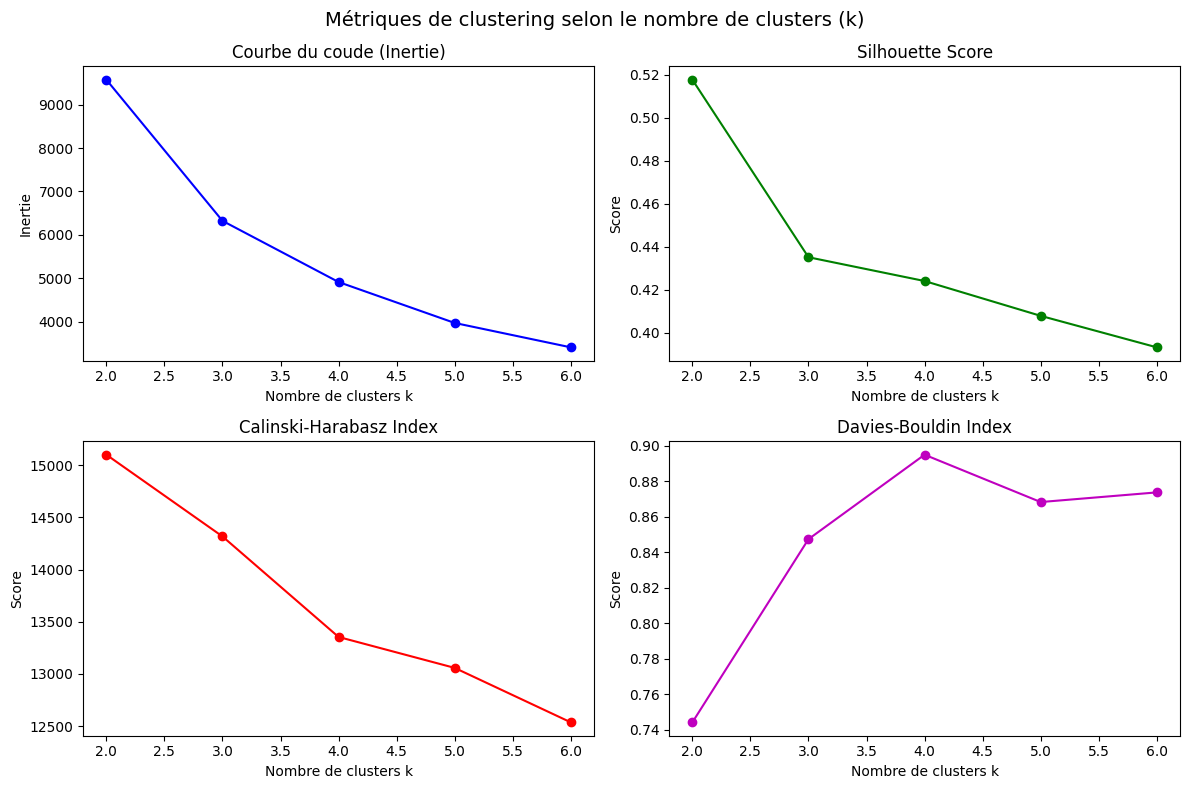

Graphique sauvegardé.


In [72]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Métriques de clustering selon le nombre de clusters (k)', fontsize=14)

axes[0,0].plot(df_resultats['k'], df_resultats['inertie'], 'bo-')
axes[0,0].set_title('Courbe du coude (Inertie)')
axes[0,0].set_xlabel('Nombre de clusters k')
axes[0,0].set_ylabel('Inertie')

axes[0,1].plot(df_resultats['k'], df_resultats['silhouette'], 'go-')
axes[0,1].set_title('Silhouette Score')
axes[0,1].set_xlabel('Nombre de clusters k')
axes[0,1].set_ylabel('Score')

axes[1,0].plot(df_resultats['k'], df_resultats['calinski_harabasz'], 'ro-')
axes[1,0].set_title('Calinski-Harabasz Index')
axes[1,0].set_xlabel('Nombre de clusters k')
axes[1,0].set_ylabel('Score')

axes[1,1].plot(df_resultats['k'], df_resultats['davies_bouldin'], 'mo-')
axes[1,1].set_title('Davies-Bouldin Index')
axes[1,1].set_xlabel('Nombre de clusters k')
axes[1,1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('metriques_clustering.png', dpi=150)
plt.show()
print('Graphique sauvegardé.')

### Lecture du tableau

On lit chaque colonne en cherchant la meilleure valeur :
- Silhouette → valeur **maximale**
- Calinski-Harabasz → valeur **maximale**
- Davies-Bouldin → valeur **minimale**

Les trois indicateurs pointent vers **K=2**.

In [73]:
# Affichage du tableau récapitulatif
print('Récapitulatif des métriques :')
df_resultats

Récapitulatif des métriques :


,k,inertie,silhouette,calinski_harabasz,davies_bouldin
0,2,9574.433392,0.517597,15099.938501,0.744123
1,3,6323.159752,0.435170,14316.915286,0.847321
2,4,4913.892245,0.424121,13353.830287,0.894886
3,5,3971.153072,0.407953,13057.574492,0.868221
4,6,3409.395975,0.393331,12535.938467,0.873660


### Choix final de K

In [74]:
# Choix du meilleur k selon le Silhouette Score
meilleur_k = df_resultats.loc[df_resultats['silhouette'].idxmax(), 'k']
print(f'Meilleur k selon Silhouette : k = {meilleur_k}')

# On permet aussi à l'utilisateur de choisir manuellement
k_choisi = 3  # pour tester 2 ou 3 catégories
# k_choisi = int(meilleur_k) logique a faire mais dans la consigne on en veut 3
print(f'k choisi pour la suite : {k_choisi}')

Meilleur k selon Silhouette : k = 2
k choisi pour la suite : 3


### Entraînement du modèle final

On sauvegarde le modèle au format `.pkl` (pickle) : c'est le modèle entraîné "congelé" qu'on pourra recharger instantanément sans recalculer.

In [75]:
# Entraînement du modèle final avec le k choisi pour l'instant 3
kmeans_final = KMeans(n_clusters=k_choisi, random_state=42, n_init=10)
df_work['cluster'] = kmeans_final.fit_predict(X_scaled)

# Sauvegarde du modèle K-Means pour le script final
joblib.dump(kmeans_final, 'models/kmeans_besoin1.pkl')
print(f'Modèle K-Means (k={k_choisi}) sauvegardé.')

# Distribution des clusters
print('\nDistribution des clusters :')
print(df_work['cluster'].value_counts().sort_index())

Modèle K-Means (k=3) sauvegardé.

Distribution des clusters :
cluster
0    2165
1    4802
2    4260
Name: count, dtype: int64


### Sauvegarde de plusieurs modèles

On sauvegarde les modèles pour K=2, 3 et 4 pour permettre au script final de fonctionner avec n'importe lequel de ces choix via le paramètre `--n_clusters`. Cela offre de la flexibilité sans avoir à réentraîner à chaque fois.

In [76]:
# Sauvegarde d'un modèle pour chaque k (2, 3, 4)
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    joblib.dump(km, f'models/kmeans_k{k}.pkl')
    print(f'Modèle k={k} sauvegardé.')

Modèle k=2 sauvegardé.
Modèle k=3 sauvegardé.
Modèle k=4 sauvegardé.


### Interprétation des clusters

Les numéros de clusters (0, 1, 2) ne veulent rien dire en eux-mêmes. Pour savoir lequel correspond aux "petits arbres" et lequel aux "grands", on calcule la **hauteur moyenne** de chaque groupe. Le groupe avec la hauteur moyenne la plus faible = petits arbres, etc.

In [77]:
# Interprétation des clusters : caractéristiques moyennes par groupe
print('Caractéristiques moyennes par cluster :')
df_work.groupby('cluster')[cols_taille].mean().round(2)

Caractéristiques moyennes par cluster :


,haut_tot,tronc_diam
cluster,,
0,19.50,169.84
1,6.13,46.05
2,10.48,113.59


### Attribution des labels lisibles

On trie les clusters par hauteur moyenne croissante (`np.argsort`) pour assigner les noms dans le bon ordre, quel que soit le numéro de cluster attribué par K-Means. Cette étape rend les résultats compréhensibles pour quelqu'un qui ne connaît pas l'algorithme.

In [78]:
# Attribution d'un label lisible selon la hauteur moyenne
# triage des clusters par hauteur totale moyenne croissante
ordre = df_work.groupby('cluster')['haut_tot'].mean().sort_values().index.tolist()

if k_choisi == 2:
    labels_map = {ordre[0]: 'Petits arbres', ordre[1]: 'Grands arbres'}
elif k_choisi == 3:
    labels_map = {ordre[0]: 'Petits arbres', ordre[1]: 'Arbres moyens', ordre[2]: 'Grands arbres'}
else:
    labels_map = {c: f'Cluster {i+1}' for i, c in enumerate(ordre)}

df_work['categorie'] = df_work['cluster'].map(labels_map)
print('Labels attribués :', labels_map)

Labels attribués : {1: 'Petits arbres', 2: 'Arbres moyens', 0: 'Grands arbres'}


## 4. Visualisation sur carte

In [79]:
couleurs = {
    'Petits arbres': '#2ecc71',
    'Arbres moyens': '#f39c12',
    'Grands arbres': '#e74c3c',
}

fig = px.scatter_map(
    df_work,
    lat='latitude',
    lon='longitude',
    color='categorie',
    color_discrete_map=couleurs,
    hover_data={'haut_tot': True, 'tronc_diam': True, 'latitude': False, 'longitude': False},
    zoom=13,
    center={'lat': df_work['latitude'].mean(), 'lon': df_work['longitude'].mean()},
    title=f'Patrimoine arboré de Saint-Quentin — {k_choisi} catégories de taille',
    map_style='open-street-map',
    opacity=0.7
)

fig.update_layout(
    legend_title_text='Catégorie',
    margin=dict(l=0, r=0, t=40, b=0),
    height=600
)

fig.write_html('carte_arbres.html')
print('Carte sauvegardée : carte_arbres.html')

Carte sauvegardée : carte_arbres.html


## 5. Résumé final

Récapitulatif des choix effectués et des performances du modèle retenu.

In [80]:
print('RÉSUMÉ BESOIN CLIENT 1')
print(f'Algorithme     : K-Means')
print(f'Nombre clusters: {k_choisi}')
print(f'Features       : {cols_taille}')
print(f'Arbres traités : {len(df_work)}')
print()

metriques_finales = df_resultats[df_resultats['k'] == k_choisi].iloc[0]
print(f'Silhouette Score    : {metriques_finales["silhouette"]:.4f}')
print(f'Calinski-Harabasz   : {metriques_finales["calinski_harabasz"]:.1f}')
print(f'Davies-Bouldin      : {metriques_finales["davies_bouldin"]:.4f}')
print()
print('Modèles sauvegardés :')
print('  - models/kmeans_besoin1.pkl')
print('  - models/scaler_besoin1.pkl')
print('Carte sauvegardée : carte_arbres.html')

RÉSUMÉ BESOIN CLIENT 1
Algorithme     : K-Means
Nombre clusters: 3
Features       : ['haut_tot', 'tronc_diam']
Arbres traités : 11227

Silhouette Score    : 0.4352
Calinski-Harabasz   : 14316.9
Davies-Bouldin      : 0.8473

Modèles sauvegardés :
  - models/kmeans_besoin1.pkl
  - models/scaler_besoin1.pkl
Carte sauvegardée : carte_arbres.html
